### Imports

In [69]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import seaborn as sns
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

TAXI_DATA_PATH = "../data/chicago_taxi_2025_clean.parquet"
WEATHER_DATA_PATH = "../data/chicago_weather_2025_hourly.csv"


# Prediction of Demand in Chicago Community Areas

This notebook focuses on forecasting taxi demand in Chicago’s 77 community areas using 4‑hour time windows. The time windows were chosen as this ensures enough data points with values, more granular data will be harder to predict. The goal is to model how demand changes across space and time, capturing patterns such as rush hours, nightlife peaks, and neighborhood‑specific behavior.

In [70]:
#Load taxi data and weather data
taxi_data = pd.read_parquet(TAXI_DATA_PATH)
weather_data = pd.read_csv(WEATHER_DATA_PATH)


In [71]:
taxi_data["pickup_community_area"].value_counts()

pickup_community_area
8     1407226
32    1007477
76     930144
28     626627
33     215516
       ...   
57       1409
64       1270
20        679
63        659
18        645
Name: count, Length: 77, dtype: int64

-> Community Area 8 has the most data points and will be used to try demand prediction first

In [72]:
# Dataframe transformation - aggregate by 1-hour time windows
taxi_data['trip_start_timestamp_rounded'] = pd.to_datetime(taxi_data['trip_start_timestamp']).dt.floor('h')
taxi_data_feats = taxi_data.groupby([taxi_data['pickup_community_area'], taxi_data['trip_start_timestamp_rounded']]).size().reset_index(name='count')

# Rename columns and extract time features
taxi_data_feats = taxi_data_feats.rename(columns={'pickup_community_area': 'community_area', 'trip_start_timestamp_rounded': 'timestamp'})

# Join weather data with taxi data on timestamp
weather_data['datetime'] = pd.to_datetime(weather_data['datetime'])
taxi_data_feats = taxi_data_feats.join(weather_data.set_index('datetime'), on='timestamp', how='left', rsuffix='_weather')

In [73]:
taxi_data_feats.info()
taxi_data_feats.head()

<class 'pandas.DataFrame'>
RangeIndex: 373122 entries, 0 to 373121
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   community_area        373122 non-null  int64         
 1   timestamp             373122 non-null  datetime64[us]
 2   count                 373122 non-null  int64         
 3   temperature_2m        373122 non-null  float64       
 4   apparent_temperature  373122 non-null  float64       
 5   precipitation         373122 non-null  float64       
 6   snowfall              373122 non-null  float64       
 7   wind_speed_10m        373122 non-null  float64       
 8   cloud_cover           373122 non-null  int64         
 9   weather_code          373122 non-null  int64         
 10  weather_description   373122 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(4), str(1)
memory usage: 34.8 MB


,community_area,timestamp,count,temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,cloud_cover,weather_code,weather_description
0,1,2025-01-01 00:00:00,2,0.7,-3.6,0.0,0.00,8.6,100,3,Overcast
1,1,2025-01-01 01:00:00,5,0.8,-3.5,0.0,0.00,8.1,100,3,Overcast
2,1,2025-01-01 02:00:00,3,0.6,-3.7,0.0,0.00,8.8,100,3,Overcast
3,1,2025-01-01 03:00:00,4,0.2,-4.8,0.1,0.07,10.7,100,71,Slight snowfall
4,1,2025-01-01 04:00:00,6,-0.2,-5.3,0.0,0.00,10.3,100,3,Overcast


## Prediction for Community Area 8 (Most Data Points)

In [74]:
# Use community area 8 for correlation analysis (most data points)
df_com_8 = taxi_data_feats[taxi_data_feats['community_area'] == 8].copy()

df_com_8.drop(columns=['community_area', 'weather_description'], inplace=True) 

df_com_8['timestamp'] = pd.to_datetime(df_com_8['timestamp'])
# Make 4-hour time windows
df_com_8['timestamp_4h'] = df_com_8['timestamp'].dt.floor('4h')
df_com_8 = df_com_8.groupby(['timestamp_4h']).agg({
    'count': 'sum',
    'temperature_2m': 'mean',
    'apparent_temperature': 'mean',
    'precipitation': 'mean',
    'snowfall': 'mean',
    'wind_speed_10m': 'mean',
    'cloud_cover': 'mean',
    'weather_code': 'mean'
}).reset_index()


df_com_8['hour'] = df_com_8['timestamp_4h'].dt.hour
df_com_8['day_of_week'] = df_com_8['timestamp_4h'].dt.dayofweek
df_com_8['month'] = df_com_8['timestamp_4h'].dt.month

# Create cyclic features for hour of day, day of week, and month
df_com_8['hour_sin'] = np.sin(2 * np.pi * df_com_8['hour'] / 24)
df_com_8['hour_cos'] = np.cos(2 * np.pi * df_com_8['hour'] / 24)
df_com_8['day_of_week_sin'] = np.sin(2 * np.pi * df_com_8['day_of_week'] / 7)
df_com_8['day_of_week_cos'] = np.cos(2 * np.pi * df_com_8['day_of_week'] / 7)
df_com_8['month_sin'] = np.sin(2 * np.pi * df_com_8['month'] / 12)
df_com_8['month_cos'] = np.cos(2 * np.pi * df_com_8['month'] / 12)


df_com_8.drop(columns=['timestamp_4h'], inplace=True) 

# Drop non-cyclic time features
df_com_8.drop(columns=['hour', 'day_of_week', 'month'], inplace=True)

df_com_8.info()


<class 'pandas.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   count                 2190 non-null   int64  
 1   temperature_2m        2190 non-null   float64
 2   apparent_temperature  2190 non-null   float64
 3   precipitation         2190 non-null   float64
 4   snowfall              2190 non-null   float64
 5   wind_speed_10m        2190 non-null   float64
 6   cloud_cover           2190 non-null   float64
 7   weather_code          2190 non-null   float64
 8   hour_sin              2190 non-null   float64
 9   hour_cos              2190 non-null   float64
 10  day_of_week_sin       2190 non-null   float64
 11  day_of_week_cos       2190 non-null   float64
 12  month_sin             2190 non-null   float64
 13  month_cos             2190 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 239.7 KB


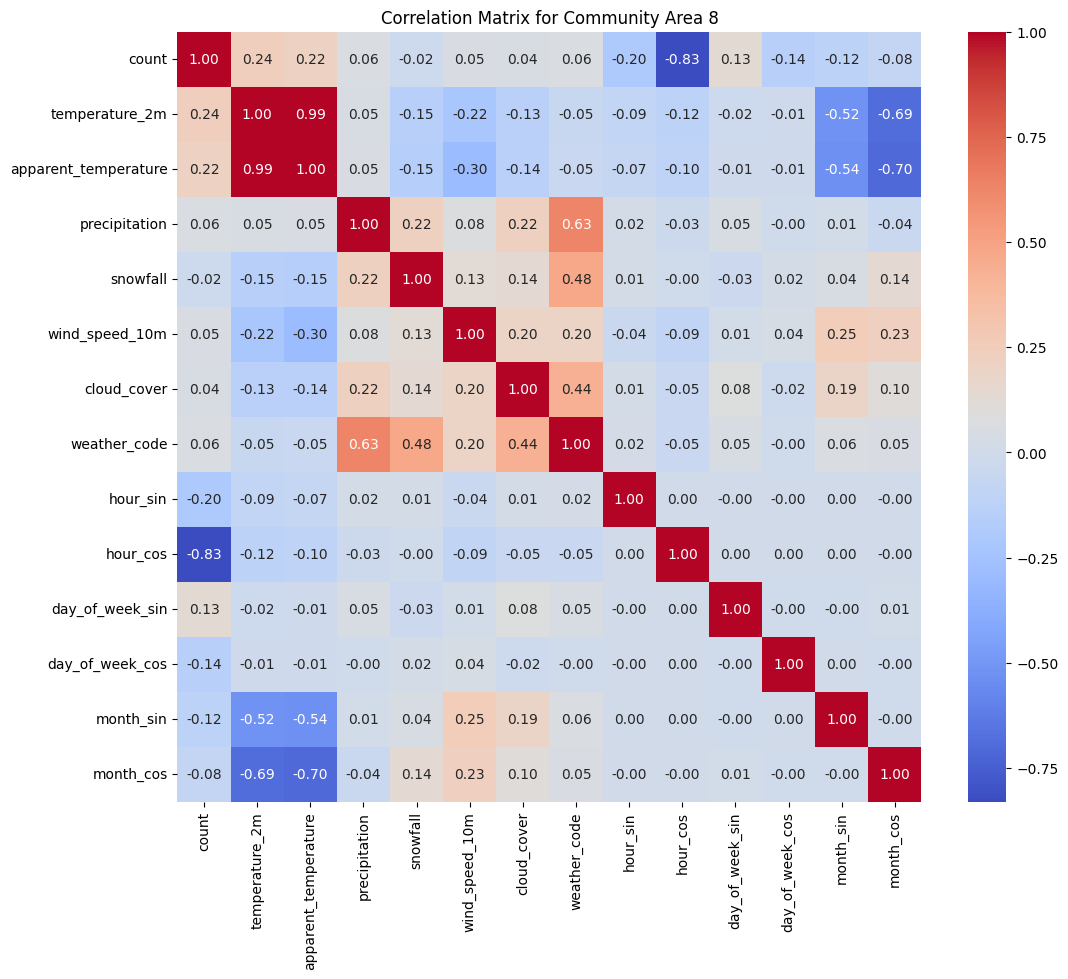

In [75]:
# Correlation matrix
corr_matrix = df_com_8.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Community Area 8')
plt.show()

In [76]:

print("Training SVM model with linear kernel for Community Area 8...\n")
print(f"Number of samples in training set: {len(df_com_8)}, (365 * 6 = 2190)\n")

X = df_com_8.drop(columns=['count'])
y = df_com_8['count']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: scaling + model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVR(kernel='linear', C=100, gamma='scale', epsilon=0.1))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Training SVM model with linear kernel for Community Area 8...

Number of samples in training set: 2190, (365 * 6 = 2190)

Mean Squared Error: 37232.44
R^2 Score: 0.79


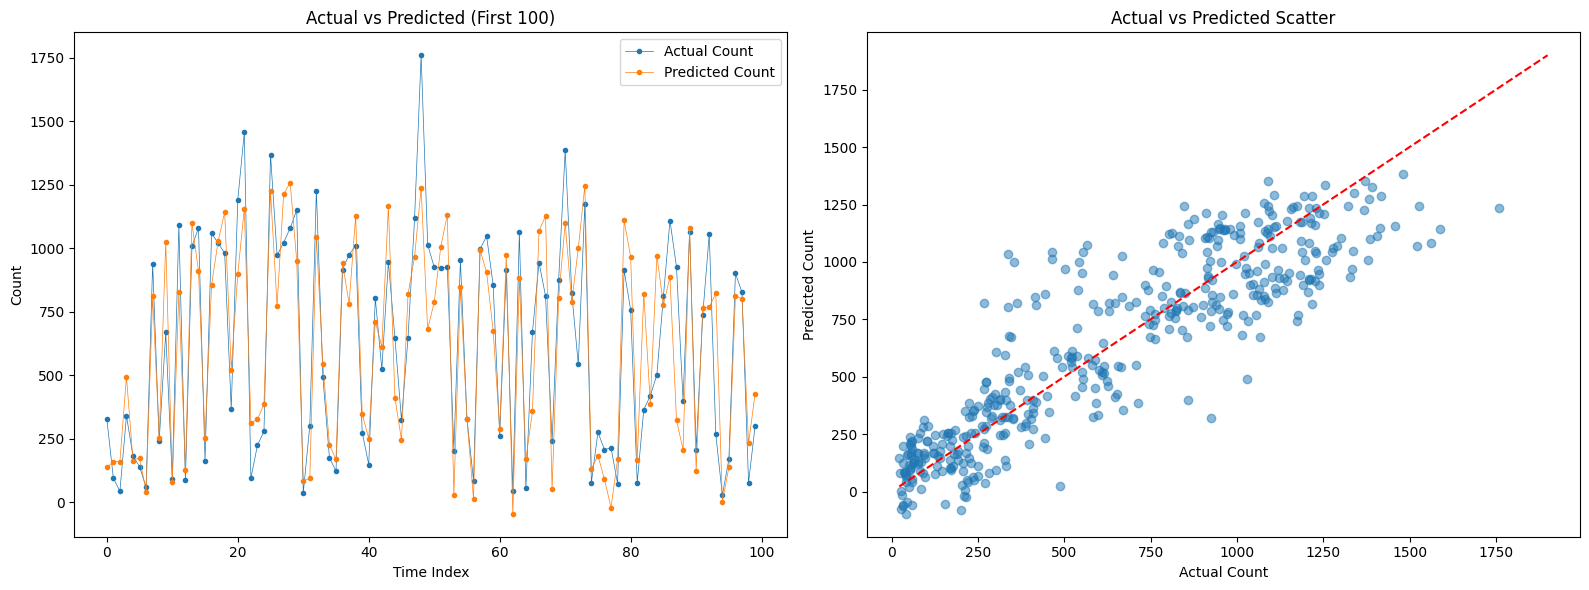

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left plot: first 100 actual vs predicted ---
axes[0].plot(y_test.reset_index(drop=True)[:100], label='Actual Count', marker='.', linewidth=0.5)
axes[0].plot(y_pred[:100], label='Predicted Count', marker='.', linewidth=0.5)
axes[0].set_xlabel('Time Index')
axes[0].set_ylabel('Count')
axes[0].set_title('Actual vs Predicted (First 100)')
axes[0].legend()

# --- Right plot: scatter actual vs predicted ---
axes[1].scatter(y_test, y_pred, alpha=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_xlabel('Actual Count')
axes[1].set_ylabel('Predicted Count')
axes[1].set_title('Actual vs Predicted Scatter')

plt.tight_layout()
plt.show()


In [78]:
print("Training SVM model with Grid Search for Community Area 8...\n")
print(f"Number of samples in training set: {len(df_com_8)}, (365 * 6 = 2190)\n")

X = df_com_8.drop(columns=['count'])
y = df_com_8['count']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline: scaling + SVR
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVR())
])

# Your parameter grid
param_grid = {
    'svm__C': [1, 10, 100, 1000],
    'svm__epsilon': [0.01, 0.1, 1],
    'svm__gamma': ['scale', 'auto', 0.01, 0.001],
    'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

# Grid search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# Evaluate on test set
y_pred = grid_search.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Training SVM model with Grid Search for Community Area 8...

Number of samples in training set: 2190, (365 * 6 = 2190)

Best parameters: {'svm__C': 1000, 'svm__epsilon': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV score: 0.8733690889439204
Mean Squared Error: 22592.85
R^2 Score: 0.88


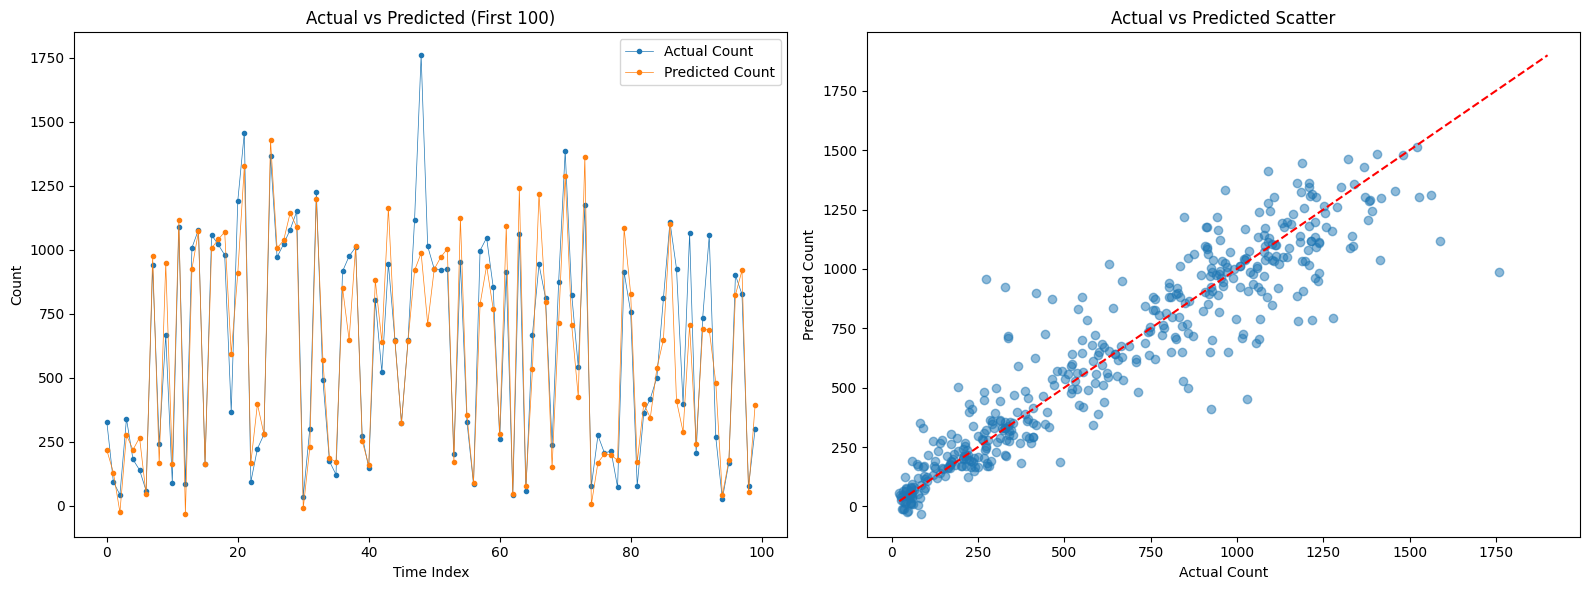

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left plot: first 100 actual vs predicted ---
axes[0].plot(y_test.reset_index(drop=True)[:100], label='Actual Count', marker='.', linewidth=0.5)
axes[0].plot(y_pred[:100], label='Predicted Count', marker='.', linewidth=0.5)
axes[0].set_xlabel('Time Index')
axes[0].set_ylabel('Count')
axes[0].set_title('Actual vs Predicted (First 100)')
axes[0].legend()

# --- Right plot: scatter actual vs predicted ---
axes[1].scatter(y_test, y_pred, alpha=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_xlabel('Actual Count')
axes[1].set_ylabel('Predicted Count')
axes[1].set_title('Actual vs Predicted Scatter')

plt.tight_layout()
plt.show()
